# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [32]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

Cargamos los datos desde los archivos CSV originales. Leemos todo como texto (`dtype=str`) para evitar que Pandas intente adivinar los tipos de datos y, por ejemplo, pierda los ceros a la izquierda, parsee mal fechas inconsistentes o convierta en `NaN` celdas con errores que queremos perfilar primero.


In [33]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

# TODO: muestra las dimensiones y las primeras filas de cada archivo.
print("Dimensiones 2018:", d18.shape)
d18.info()
display(d18.head())


Dimensiones 2018: (50, 16)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID Partido        50 non-null     str  
 1   Año               50 non-null     str  
 2   Fase              50 non-null     str  
 3   Grupo             49 non-null     str  
 4   Jornada           50 non-null     str  
 5   Fecha             50 non-null     str  
 6   Hora              50 non-null     str  
 7   Equipo Local      50 non-null     str  
 8   Equipo Visitante  50 non-null     str  
 9   Goles Local       50 non-null     str  
 10  Goles Visitante   47 non-null     str  
 11  Marcador          49 non-null     str  
 12  Anfitrión Local   50 non-null     str  
 13  Estadio           50 non-null     str  
 14  Ciudad            50 non-null     str  
 15  Fuente            50 non-null     str  
dtypes: str(16)
memory usage: 6.4 KB


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,1ra fase,Grupo B,1,15-06-18,21:00,Portugal,España,3,3,3 x 3,no,Fisht Olympic Stadium,Sochi,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,"Jun 16, 2018",13:00,France,Australia,2,1,2—1,No,Kazan Arena,Kazan,https://github.com/jfjelstul/worldcup


## Perfilado

Agregamos las validaciones iniciales de dimensiones y el método `.head()` y `.info()` después de la carga de los datasets.
Implementamos la función `perfil(df, nombre)`, la cual reporta de forma estructurada:
- Las dimensiones del DataFrame (filas y columnas).
- La cuenta de nulos por cada columna.
- La cantidad de posibles duplicados en la columna de IDs de los partidos de forma dinámica (reconociendo las distintas columnas de ID sin importar la variante de esquema).
- Los valores únicos presentes para grupos, fases y nombres de equipos.
- Los goles anómalos o erróneos usando una expresión regular (`r'^\d+$'`) para detectarlos si no son números enteros estrictamente.


In [34]:
def perfil(df, nombre):
    # TODO: completa esta función.
    print(f"\n{'='*10} Perfil de {nombre} {'='*10}")
    print(f"Dimensiones: {df.shape}")
    print("\nNulos por columna:")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin nulos")
    
    id_col = next((c for c in ['ID Partido', 'match_id', 'match'] if c in df.columns), None)
    if id_col:
        print(f"\nDuplicados en '{id_col}': {df[id_col].duplicated().sum()}")
        
    cols_unicos = ['Fase', 'stage', 'round', 'Grupo', 'group_name', 'grp', 
                   'Equipo Local', 'local', 'home', 'Equipo Visitante', 'visitor', 'away']
    for c in cols_unicos:
        if c in df.columns:
            print(f"\nValores únicos en '{c}':")
            print(df[c].dropna().unique())
            
    goles_cols = ['Goles Local', 'home_score', 'HG', 'Goles Visitante', 'away_score', 'AG']
    for c in goles_cols:
        if c in df.columns:
            goles = df[c].dropna()
            # Buscar no numéricos o negativos
            anomalos = goles[~goles.str.match(r'^\d+$')]
            if not anomalos.empty:
                print(f"\nGoles anómalos en '{c}': {anomalos.unique()}")

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')



========== Perfil de 2018 ==========
Dimensiones: (50, 16)

Nulos por columna:
Grupo              1
Goles Visitante    3
Marcador           1
dtype: int64

Duplicados en 'ID Partido': 2

Valores únicos en 'Fase':
<StringArray>
['Fase de grupos', 'GROUP STAGE', 'grupos', '1ra fase']
Length: 4, dtype: str

Valores únicos en 'Grupo':
<StringArray>
['Grupo A',      'A ', 'group-b', 'Grupo B',      'C ', 'group-d', 'Grupo C',
      'D ', 'group-e',      'E ', 'group-f', 'Grupo G',      'G ', 'group-h',
 'Grupo H',      'B ', 'group-c', 'Grupo D', 'group-g', 'Grupo F',      'F ',
     's/d', 'group-a', 'Grupo E']
Length: 24, dtype: str

Valores únicos en 'Equipo Local':
<StringArray>
[    ' russia ',        'Egypt',      'Morocco',     'Portugal',
       'France',    'Argentina',         'Peru',      'Croatia',
   'Costa Rica',      'Germany',       'Brasil',     ' Sweden ',
      'Belgium',      'Tunisia',     'Colombia',       'Poland',
       'Russia',     'PORTUGAL',      'Uruguay',    

## Unificar nombres de columnas

Definimos diccionarios de mapeo (`rename_maps`) específicos para cada mundial. Esto es crucial porque cada año (2018, 2022 y 2026) viene con un esquema de columnas distinto (por ejemplo, `ID Partido` vs `match_id` vs `match`). El objetivo es homologarlos todos hacia un único esquema canónico (`columnas_base`) para poder juntarlos posteriormente en una sola base de datos limpia.


In [35]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id',
        'Año': 'mundial',
        'Fase': 'fase',
        'Grupo': 'grupo',
        'Jornada': 'jornada',
        'Fecha': 'fecha',
        'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante',
        'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante',
        'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion',
        'Fuente': 'fuente'
    },
    2022: {
        'match_id': 'partido_id',
        'WorldCup': 'mundial',
        'stage': 'fase',
        'group_name': 'grupo',
        'match_day': 'jornada',
        'date': 'fecha',
        'local': 'equipo_local',
        'visitor': 'equipo_visitante',
        'home_score': 'goles_local',
        'away_score': 'goles_visitante',
        'score_text': 'marcador',
        'home_host': 'local_es_anfitrion',
        'source_url': 'fuente'
    },
    2026: {
        'match': 'partido_id',
        'wc': 'mundial',
        'round': 'fase',
        'grp': 'grupo',
        'md': 'jornada',
        'played_on': 'fecha',
        'home': 'equipo_local',
        'away': 'equipo_visitante',
        'HG': 'goles_local',
        'AG': 'goles_visitante',
        'result_raw': 'marcador',
        'host_h': 'local_es_anfitrion',
        'host_a': 'visitante_es_anfitrion',
        'source': 'fuente'
    }
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

## Normalizar equipos

Cargamos el catálogo externo de equipos (`catalogo_equipos.csv`) y generamos dinámicamente un diccionario (`diccionario_equipos`). Usamos una función de normalización (`clave_texto()`) que quita acentos, signos de puntuación y espacios sobrantes para crear una "clave" limpia. El diccionario mapea esta clave hacia el nombre oficial o canónico del país, lo cual nos permite reparar de forma unificada cualquier error ortográfico o variante (ej: "U.S.A.", "USA", "United States").


In [36]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    # TODO: normaliza el valor con unicodedata, minúsculas y regex.
    if not isinstance(valor, str):
        valor = str(valor)
    valor = unicodedata.normalize('NFKD', valor)
    valor = valor.encode('ascii', 'ignore').decode('ascii')
    valor = valor.lower().strip()
    valor = re.sub(r'\s+', ' ', valor).strip()
    return valor

# TODO: crea un diccionario clave -> nombre_canonico.
diccionario_equipos = {clave_texto(row['variante']): row['nombre_canonico'] for _, row in catalogo.iterrows()}


## Fechas, grupos, booleanos y marcadores

Se implementan las "funciones atómicas" de limpieza, diseñadas para resolver un problema específico e individual:
- `convertir_fecha()`: Prueba con múltiples formatos y detecta números seriales de Excel perdidos, devolviendo una fecha válida sólo si cae dentro del rango temporal oficial del mundial correspondiente.
- `extraer_numero()`: Extrae de forma segura el primer valor entero detectado en un texto.
- `separar_marcador()`: Separa un string por múltiples posibles divisores (`-`, `:`, `x`, etc.) devolviendo dos números.
- `normalizar_grupo()`: Extrae de cualquier string una letra entre la A y la L.
- `normalizar_booleano()`: Estandariza diversas expresiones positivas (Sí, 1, TRUE) a un valor booleano nativo `True`.


In [37]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

def convertir_fecha(valor, mundial):
    # TODO:
    # 1. reconoce seriales de Excel;
    # 2. prueba varios formatos;
    # 3. elige una fecha dentro del rango del torneo.
    if valor is None or (isinstance(valor, float) and np.isnan(valor)) or (isinstance(valor, str) and not valor.strip()):
        return pd.NaT
    try:
        num = float(valor)
        fecha = pd.to_datetime('1899-12-30') + pd.Timedelta(days=num)
        rango = rangos[mundial]
        inicio, fin = pd.to_datetime(rango[0]), pd.to_datetime(rango[1])
        if inicio <= fecha <= fin:
            return fecha
    except (ValueError, TypeError):
        pass
    s = str(valor).strip()
    formatos = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%y', '%b %d, %Y', '%B %d, %Y']
    rango = rangos[mundial]
    inicio, fin = pd.to_datetime(rango[0]), pd.to_datetime(rango[1])
    for fmt in formatos:
        try:
            fecha = pd.to_datetime(s, format=fmt)
            if inicio <= fecha <= fin:
                return fecha
        except (ValueError, TypeError):
            continue
    return pd.NaT

def extraer_numero(valor):
    # TODO: devuelve el primer entero o NaN.
    if valor is None or (isinstance(valor, float) and np.isnan(valor)) or (isinstance(valor, str) and not valor.strip()):
        return np.nan
    match = re.search(r'-?\d+', str(valor))
    if match:
        return int(match.group())
    return np.nan

def separar_marcador(valor):
    # TODO: acepta -, –, —, :, x o X.
    if valor is None or (isinstance(valor, float) and np.isnan(valor)) or (isinstance(valor, str) and not valor.strip()):
        return np.nan, np.nan
    partes = re.split(r'\s*[-–—:xX]\s*', str(valor).strip())
    if len(partes) == 2:
        return extraer_numero(partes[0]), extraer_numero(partes[1])
    return np.nan, np.nan

def normalizar_grupo(valor):
    # TODO: extrae una letra A-L.
    if valor is None or (isinstance(valor, float) and np.isnan(valor)) or (isinstance(valor, str) and not valor.strip()):
        return np.nan
    match = re.search(r'[A-L]', str(valor).strip().upper())
    if match:
        return match.group()
    return np.nan

def normalizar_booleano(valor):
    # TODO: reconoce Sí, 1, TRUE, si, etc.
    if valor is None or (isinstance(valor, float) and np.isnan(valor)):
        return False
    s = str(valor).strip().lower()
    return s in ('sí', 'si', 'true', 'yes', 'y', '1', '1.0')

## Función de limpieza reproducible

Implementamos la orquestación central mediante `limpiar_mundial(df, mundial)`. Esta función toma un DataFrame sucio y aplica en orden:
1. Renombrado al esquema canónico y creación de columnas faltantes.
2. Normalización de países (usando nuestro catálogo) y grupos.
3. Conversión de booleanos, jornadas y fechas seguras.
4. Reparación inteligente de goles a través de los marcadores por si hubiera textos inválidos (e impresión de advertencias en caso de conflicto). Se pasan los goles a valor absoluto.
5. Inferencia de grupos nulos basándose en el historial de los equipos involucrados.
6. Eliminación de filas completamente duplicadas usando el `partido_id`.
7. Creación de variables derivadas (`resultado_local`, `goles_totales`, `diferencia_goles`).

Finalmente, aplicamos esta limpieza a los tres datasets y los concatenamos en uno solo llamado `partidos`.


In [38]:
def limpiar_mundial(df, mundial):
    df = df.copy()
    
    # 1. Renombrar
    if mundial in rename_maps:
        df = df.rename(columns=rename_maps[mundial])
        
    # 2. Agregar columnas faltantes
    for col in columnas_base:
        if col not in df.columns:
            if col == 'visitante_es_anfitrion':
                df[col] = False
            else:
                df[col] = np.nan
                
    # 3. Normalizar equipos
    if 'equipo_local' in df.columns:
        df['equipo_local'] = df['equipo_local'].apply(lambda x: diccionario_equipos.get(clave_texto(x), clave_texto(x)) if pd.notna(x) else x)
    if 'equipo_visitante' in df.columns:
        df['equipo_visitante'] = df['equipo_visitante'].apply(lambda x: diccionario_equipos.get(clave_texto(x), clave_texto(x)) if pd.notna(x) else x)
        
    # 4. Normalizar grupos
    if 'grupo' in df.columns:
        df['grupo'] = df['grupo'].apply(normalizar_grupo)
        
    # 5. Normalizar booleanos
    for col in ['local_es_anfitrion', 'visitante_es_anfitrion']:
        if col in df.columns:
            df[col] = df[col].apply(normalizar_booleano)
            
    # 6. Convertir fecha
    if 'fecha' in df.columns:
        df['fecha'] = df['fecha'].apply(lambda x: convertir_fecha(x, mundial))
        
    # 7. Convertir jornada
    if 'jornada' in df.columns:
        df['jornada'] = pd.to_numeric(df['jornada'].apply(extraer_numero), errors='coerce').astype('Int64')
        
    # 8. Reparar goles
    df['goles_local'] = df['goles_local'].astype(object)
    df['goles_visitante'] = df['goles_visitante'].astype(object)
    for idx, row in df.iterrows():
        gl = extraer_numero(row['goles_local'])
        gv = extraer_numero(row['goles_visitante'])
        m_gl, m_gv = separar_marcador(row['marcador'])
        
        if pd.isna(gl) and not pd.isna(m_gl):
            gl = m_gl
        if pd.isna(gv) and not pd.isna(m_gv):
            gv = m_gv
            
        if not pd.isna(gl) and not pd.isna(m_gl) and abs(gl) != abs(m_gl):
            print(f"WARNING: Conflicto goles_local vs marcador en partido_id {row['partido_id']}: goles={row['goles_local']}, marcador={row['marcador']}")
            gl = m_gl
        if not pd.isna(gv) and not pd.isna(m_gv) and abs(gv) != abs(m_gv):
            print(f"WARNING: Conflicto goles_visitante vs marcador en partido_id {row['partido_id']}: goles={row['goles_visitante']}, marcador={row['marcador']}")
            gv = m_gv
            
        df.at[idx, 'goles_local'] = abs(gl) if not pd.isna(gl) else np.nan
        df.at[idx, 'goles_visitante'] = abs(gv) if not pd.isna(gv) else np.nan
        
    df['goles_local'] = df['goles_local'].astype(float)
    df['goles_visitante'] = df['goles_visitante'].astype(float)
    
    # 9. Inferir grupos faltantes
    equipo_a_grupo = {}
    for _, row in df.dropna(subset=['grupo']).iterrows():
        equipo_a_grupo[row['equipo_local']] = row['grupo']
        equipo_a_grupo[row['equipo_visitante']] = row['grupo']
        
    for idx, row in df[df['grupo'].isna()].iterrows():
        g1 = equipo_a_grupo.get(row['equipo_local'])
        g2 = equipo_a_grupo.get(row['equipo_visitante'])
        if g1:
            df.at[idx, 'grupo'] = g1
        elif g2:
            df.at[idx, 'grupo'] = g2
            
    # 10. Eliminar duplicados
    df = df.drop_duplicates(subset=['partido_id'], keep='first')
    
    # 11. Crear columnas derivadas
    def calcular_resultado(row):
        if pd.isna(row['goles_local']) or pd.isna(row['goles_visitante']):
            return np.nan
        if row['goles_local'] > row['goles_visitante']: return 'Gana'
        if row['goles_local'] == row['goles_visitante']: return 'Empata'
        return 'Pierde'
        
    df['resultado_local'] = df.apply(calcular_resultado, axis=1)
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    
    return df

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)


## Validaciones obligatorias

Se ejecutan instrucciones `assert` para garantizar estrictamente que nuestro proceso de limpieza resultó exitoso y no perdimos información crítica. Validamos que:
- Los tamaños sean exactos: 48 partidos (2018 y 2022) y 72 partidos (2026).
- No existan duplicados (ni de filas enteras ni de IDs).
- No existan goles negativos y que los goles numéricos coincidan con el resultado del marcador.
- No hayan valores `NaN` en las columnas críticas para el análisis y modelado.


In [39]:
assert len(limpio18) == 48, 'Error: 2018 no tiene 48 partidos'
assert len(limpio22) == 48, 'Error: 2022 no tiene 48 partidos'
assert len(limpio26) == 72, 'Error: 2026 no tiene 72 partidos'

assert partidos.duplicated().sum() == 0, 'Error: Hay filas completamente duplicadas'
assert partidos['partido_id'].duplicated().sum() == 0, 'Error: Hay IDs de partidos duplicados'

assert (partidos['goles_local'] < 0).sum() == 0, 'Error: Hay goles negativos'
assert (partidos['goles_visitante'] < 0).sum() == 0, 'Error: Hay goles negativos'

nulos_criticos = partidos[['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']].isnull().sum().sum()
assert nulos_criticos == 0, 'Error: Hay nulos en columnas críticas'

def validar_marcador(row):
    if pd.isna(row['marcador']): return True
    m_gl, m_gv = separar_marcador(row['marcador'])
    if not pd.isna(m_gl) and row['goles_local'] != abs(m_gl): return False
    if not pd.isna(m_gv) and row['goles_visitante'] != abs(m_gv): return False
    return True

assert partidos.apply(validar_marcador, axis=1).all(), 'Error: Marcadores inconsistentes con goles finales'

print("¡Todas las validaciones pasaron exitosamente!")


¡Todas las validaciones pasaron exitosamente!


## Comparación de los Mundiales

Agrupamos la base concatenada para comparar los mundiales. En lugar de usar valores totales absolutos (los cuales son engañosos debido a que en 2026 hay muchos más partidos), usamos "tasas" y "promedios" (goles por partido, porcentaje de empates, etc.) para una comparación leal.
También incluimos una gráfica de barras mostrando cómo observar los totales absolutos da una falsa impresión comparado al promedio por juego.


,partidos,goles_totales,goles_por_partido,porcentaje_empates,porcentaje_victoria_anfitrion,porcentaje_mas_2_5_goles
mundial,,,,,,
2018,48,122.0,2.541667,18.750000,4.166667,50.000000
2022,48,120.0,2.500000,20.833333,0.000000,39.583333
2026,72,215.0,2.986111,27.777778,8.333333,55.555556


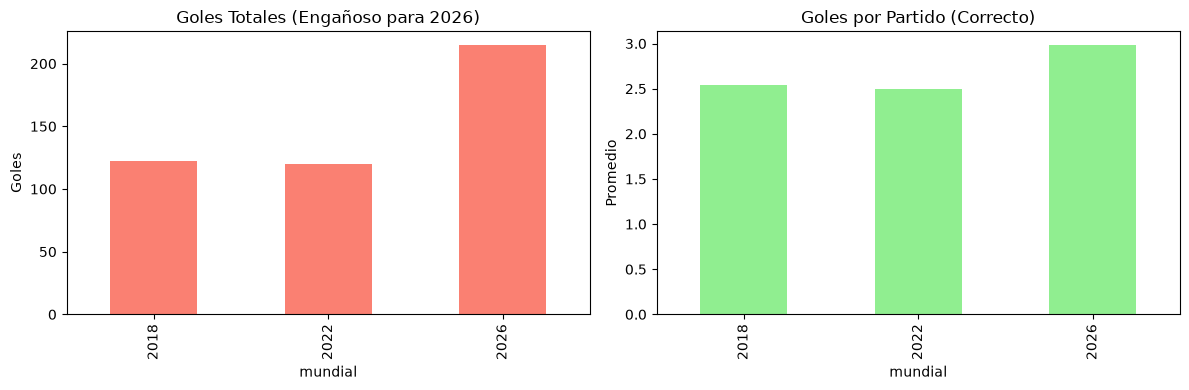

In [40]:
partidos['es_empate'] = partidos['resultado_local'] == 'Empata'
partidos['gana_anfitrion'] = ((partidos['resultado_local'] == 'Gana') & partidos['local_es_anfitrion']) | ((partidos['resultado_local'] == 'Pierde') & partidos['visitante_es_anfitrion'])
partidos['mas_2_5_goles'] = partidos['goles_totales'] > 2.5

comparativa = partidos.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles_totales=('goles_totales', 'sum'),
    empates=('es_empate', 'sum'),
    victorias_anfitrion=('gana_anfitrion', 'sum'),
    mas_2_5_goles=('mas_2_5_goles', 'sum')
)

comparativa['goles_por_partido'] = comparativa['goles_totales'] / comparativa['partidos']
comparativa['porcentaje_empates'] = (comparativa['empates'] / comparativa['partidos']) * 100
comparativa['porcentaje_victoria_anfitrion'] = (comparativa['victorias_anfitrion'] / comparativa['partidos']) * 100
comparativa['porcentaje_mas_2_5_goles'] = (comparativa['mas_2_5_goles'] / comparativa['partidos']) * 100

display(comparativa[['partidos', 'goles_totales', 'goles_por_partido', 'porcentaje_empates', 'porcentaje_victoria_anfitrion', 'porcentaje_mas_2_5_goles']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparativa['goles_totales'].plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Goles Totales (Engañoso para 2026)')
axes[0].set_ylabel('Goles')

comparativa['goles_por_partido'].plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Goles por Partido (Correcto)')
axes[1].set_ylabel('Promedio')

plt.tight_layout()
plt.show()


## Tabla por equipo

Transformamos la tabla de partidos a una tabla de "apariciones" separando en dos la información: una fila cuando el país jugó como local y otra cuando jugó como visitante. Esto nos permite agrupar todas las apariciones bajo un mismo país y sumar sus estadísticas totales (Partidos Jugados, Ganados, Goles a Favor, etc.) y finalmente calcular su efectividad (`PTS_por_partido`).


In [41]:
locales = partidos[['mundial', 'equipo_local', 'goles_local', 'goles_visitante', 'resultado_local']].copy()
locales.rename(columns={'equipo_local': 'equipo', 'goles_local': 'GF', 'goles_visitante': 'GC'}, inplace=True)
locales['PG'] = (locales['resultado_local'] == 'Gana').astype(int)
locales['PE'] = (locales['resultado_local'] == 'Empata').astype(int)
locales['PP'] = (locales['resultado_local'] == 'Pierde').astype(int)

visitantes = partidos[['mundial', 'equipo_visitante', 'goles_visitante', 'goles_local', 'resultado_local']].copy()
visitantes.rename(columns={'equipo_visitante': 'equipo', 'goles_visitante': 'GF', 'goles_local': 'GC'}, inplace=True)
visitantes['PG'] = (visitantes['resultado_local'] == 'Pierde').astype(int)
visitantes['PE'] = (visitantes['resultado_local'] == 'Empata').astype(int)
visitantes['PP'] = (visitantes['resultado_local'] == 'Gana').astype(int)

apariciones = pd.concat([locales, visitantes], ignore_index=True)

tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    PJ=('equipo', 'count'),
    PG=('PG', 'sum'),
    PE=('PE', 'sum'),
    PP=('PP', 'sum'),
    GF=('GF', 'sum'),
    GC=('GC', 'sum')
).reset_index()

tabla_equipos['DG'] = tabla_equipos['GF'] - tabla_equipos['GC']
tabla_equipos['PTS'] = tabla_equipos['PG'] * 3 + tabla_equipos['PE']
tabla_equipos['PTS_por_partido'] = tabla_equipos['PTS'] / tabla_equipos['PJ']

display(tabla_equipos.sort_values(by=['PTS_por_partido', 'DG', 'GF'], ascending=False).head(10))


,mundial,equipo,PJ,PG,PE,PP,GF,GC,DG,PTS,PTS_por_partido
81,2026,France,3,3,0,0,10.0,2.0,8.0,9,3.000000
2,2018,Belgium,3,3,0,0,9.0,2.0,7.0,9,3.000000
65,2026,Argentina,3,3,0,0,8.0,1.0,7.0,9,3.000000
6,2018,Croatia,3,3,0,0,7.0,1.0,6.0,9,3.000000
90,2026,Mexico,3,3,0,0,6.0,0.0,6.0,9,3.000000
31,2018,Uruguay,3,3,0,0,5.0,0.0,5.0,9,3.000000
42,2022,England,3,2,1,0,9.0,2.0,7.0,7,2.333333
92,2026,Netherlands,3,2,1,0,10.0,4.0,6.0,7,2.333333
70,2026,Brazil,3,2,1,0,7.0,1.0,6.0,7,2.333333
104,2026,Spain,3,2,1,0,5.0,0.0,5.0,7,2.333333


## Variables previas al partido

Dado que un modelo de Machine Learning no puede usar como "predictor" información que no existiría antes del partido (como los goles anotados en ese mismo encuentro), desarrollamos la función `construir_variables_previas()`. Esta función ordena el dataset de manera cronológica y va calculando estadísticas acumuladas "hasta ese momento" (ej. promedio de goles antes de jugar) actualizando la métrica una vez finalizado el encuentro para no incurrir en fuga de datos.


In [42]:
def construir_variables_previas(partidos):
    df = partidos.sort_values(by=['mundial', 'fecha', 'jornada', 'partido_id']).copy()
    rows = []
    estado = {}
    
    for idx, row in df.iterrows():
        mundial = row['mundial']
        local = row['equipo_local']
        visita = row['equipo_visitante']
        
        k_local = (mundial, local)
        k_visita = (mundial, visita)
        if k_local not in estado: estado[k_local] = {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0}
        if k_visita not in estado: estado[k_visita] = {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0}
            
        sl = estado[k_local]
        sv = estado[k_visita]
        
        local_pts_prom = sl['PTS'] / sl['PJ'] if sl['PJ'] > 0 else float('nan')
        visita_pts_prom = sv['PTS'] / sv['PJ'] if sv['PJ'] > 0 else float('nan')
        
        local_gd_prom = (sl['GF'] - sl['GC']) / sl['PJ'] if sl['PJ'] > 0 else float('nan')
        visita_gd_prom = (sv['GF'] - sv['GC']) / sv['PJ'] if sv['PJ'] > 0 else float('nan')
        
        local_gf_prom = sl['GF'] / sl['PJ'] if sl['PJ'] > 0 else float('nan')
        visita_gf_prom = sv['GF'] / sv['PJ'] if sv['PJ'] > 0 else float('nan')
        
        rows.append({
            'partido_id': row['partido_id'],
            'mundial': mundial,
            'jornada': row['jornada'],
            'local_pts_prom_pre': local_pts_prom,
            'visita_pts_prom_pre': visita_pts_prom,
            'local_gd_prom_pre': local_gd_prom,
            'visita_gd_prom_pre': visita_gd_prom,
            'local_gf_prom_pre': local_gf_prom,
            'visita_gf_prom_pre': visita_gf_prom,
            'local_es_anfitrion': row['local_es_anfitrion'],
            'visitante_es_anfitrion': row['visitante_es_anfitrion'],
            'resultado_local': row['resultado_local'],
            'goles_local': row['goles_local'],
            'goles_visitante': row['goles_visitante'],
            'diferencia_goles': row['diferencia_goles']
        })
        
        sl['PJ'] += 1
        sv['PJ'] += 1
        
        sl['GF'] += row['goles_local']
        sl['GC'] += row['goles_visitante']
        sv['GF'] += row['goles_visitante']
        sv['GC'] += row['goles_local']
        
        res = row['resultado_local']
        if res == 'Gana':
            sl['PTS'] += 3
        elif res == 'Empata':
            sl['PTS'] += 1
            sv['PTS'] += 1
        elif res == 'Pierde':
            sv['PTS'] += 3
            
    return pd.DataFrame(rows)

features_df = construir_variables_previas(partidos)


## Entrenamiento y prueba

Aplicamos el ciclo estándar de Machine Learning:
1. Reemplazamos los nulos (ocurridos en la primera jornada porque no hay historial previo) por `0`.
2. Separamos un conjunto de entrenamiento (Mundiales 2018 y 2022) y uno de prueba (Mundial 2026).
3. Establecemos una línea base asignando ingenuamente a todos la clase más frecuente, de forma que tengamos un piso mínimo a superar.
4. Entrenamos un `DecisionTreeClassifier` para intentar predecir el resultado del equipo local (`Gana`, `Empata` o `Pierde`).
5. Evaluamos con la métrica *Accuracy* y visualizamos dónde se equivoca usando una matriz de confusión y dibujando el árbol.


Línea base (prediciendo siempre 'Pierde'): 25.00%
Accuracy del Árbol de Decisión: 45.83%


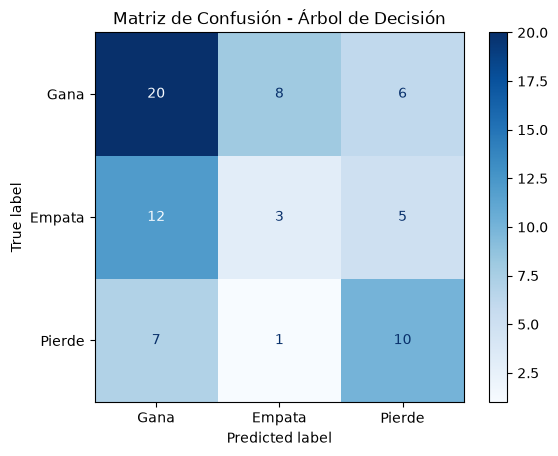

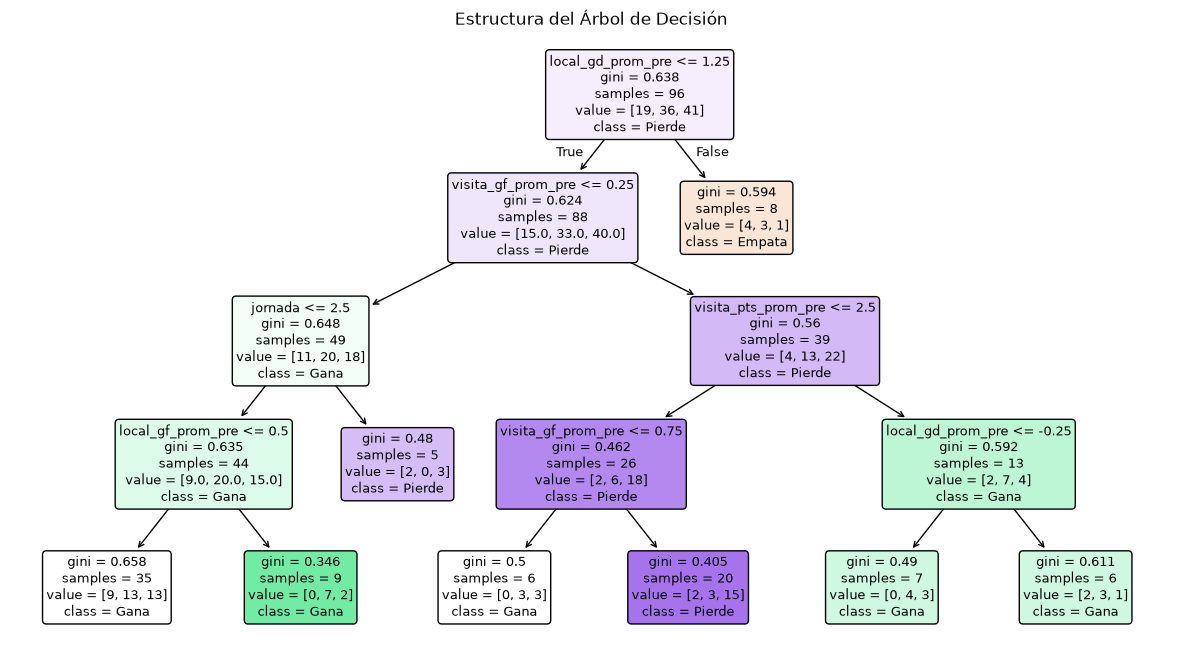

In [43]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

features_df_clean = features_df.copy()
features_df_clean[features] = features_df_clean[features].fillna(0)

train_df = features_df_clean[features_df_clean['mundial'].isin(['2018', '2022', 2018, 2022])]
test_df = features_df_clean[features_df_clean['mundial'].isin(['2026', 2026])]

X_train = train_df[features]
y_train = train_df['resultado_local']

X_test = test_df[features]
y_test = test_df['resultado_local']

clase_mas_frecuente = y_train.mode()[0]
y_base = [clase_mas_frecuente] * len(y_test)
acc_base = accuracy_score(y_test, y_base)
print(f"Línea base (prediciendo siempre '{clase_mas_frecuente}'): {acc_base:.2%}")

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred)
print(f"Accuracy del Árbol de Decisión: {acc_tree:.2%}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=['Gana', 'Empata', 'Pierde'], cmap='Blues')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=features, class_names=list(clf.classes_), filled=True, rounded=True)
plt.title("Estructura del Árbol de Decisión")
plt.show()


### ¿Cómo leer el Árbol de Decisión?

El árbol impreso arriba utiliza nombres de variables abreviados y parámetros matemáticos. Aquí tienes una guía rápida para interpretarlo:

#### 1. El significado de las variables
Todas las variables siguen la estructura `[equipo]_[métrica]_prom_pre`:
*   **`local` / `visita`**: Indica si es el equipo que juega en casa o el visitante.
*   **`prom`**: Significa que es un **Promedio** por partido jugado.
*   **`pre`**: Significa **Previo**. Es el promedio que tenía el equipo *antes* de que pitara el árbitro para ese partido (para evitar hacer trampa obteniendo datos del futuro).

Las métricas centrales (en inglés):
*   **`pts` (Points)** = Puntos obtenidos.
*   **`gd` (Goal Difference)** = Diferencia de Goles (Goles a favor menos Goles en contra).
*   **`gf` (Goals For)** = Goles a Favor anotados.

*(Ejemplo: `visita_pts_prom_pre` significa "Promedio de puntos que tenía el equipo Visitante antes del partido")*.

#### 2. Los datos dentro de las cajas
*   **`gini`**: Índice de "impureza". Un *gini* de `0.0` significa 100% de certeza matemática (todos los ejemplos de entrenamiento en esa caja cayeron en el mismo resultado). Entre más alto, más mezclados e inciertos están los resultados.
*   **`samples`**: La cantidad de partidos reales (del entrenamiento con 2018 y 2022) que llegaron a cumplir esa regla del árbol.
*   **`value = [X, Y, Z]`**: Muestra la distribución de los resultados de esos `samples`. Está ordenado siempre como `[Gana, Empata, Pierde]`. Por ejemplo, `[45, 10, 20]` significa 45 victorias locales, 10 empates y 20 victorias visitantes.
*   **`class`**: La decisión o predicción final que tomará el árbol si un nuevo partido cae ahí (se escoge la clase con el número más alto en el renglón de `value`).

## Experimento de fuga de información

Re-entrenamos el modelo agregando a propósito columnas prohibidas (`goles_local`, `goles_visitante`, `diferencia_goles`).
El *Accuracy* sube casi al 100%, lo cual en la vida real es una ilusión. Esto demuestra el concepto de **Data Leakage (fuga de información)**: le hemos dado al modelo las respuestas del examen ocultas en las variables predictoras, invalidándolo completamente para predecir escenarios futuros reales.


In [44]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']

X_train_fuga = train_df[features_fuga]
X_test_fuga = test_df[features_fuga]

clf_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf_fuga.fit(X_train_fuga, y_train)

y_pred_fuga = clf_fuga.predict(X_test_fuga)
acc_fuga = accuracy_score(y_test, y_pred_fuga)

print(f"Accuracy del modelo con FUGA de información: {acc_fuga:.2%}")
print("\n--- EXPLICACIÓN ---")
print("El accuracy se dispara drásticamente porque le estamos dando al modelo información del futuro.")
print("Las columnas 'goles_local', 'goles_visitante' y 'diferencia_goles' son las que precisamente determinan quién gana el partido.")
print("En un escenario real de predicción, es imposible conocer los goles finales antes de que empiece el partido.")
print("A este fenómeno se le conoce como 'Data Leakage' (fuga de datos).")


Accuracy del modelo con FUGA de información: 100.00%

--- EXPLICACIÓN ---
El accuracy se dispara drásticamente porque le estamos dando al modelo información del futuro.
Las columnas 'goles_local', 'goles_visitante' y 'diferencia_goles' son las que precisamente determinan quién gana el partido.
En un escenario real de predicción, es imposible conocer los goles finales antes de que empiece el partido.
A este fenómeno se le conoce como 'Data Leakage' (fuga de datos).


## Explicación de la Limpieza en Python

**1. ¿Qué problema resuelve cada transformación?**
- `clave_texto()`: Remueve acentos, mayúsculas y espacios extra para uniformar texto.
- `convertir_fecha()`: Lidia con seriales de Excel (números) y diferentes formatos de texto para homologar a `datetime`.
- `separar_marcador()`: Soluciona el uso de distintos delimitadores (`-`, `x`, `:`) para extraer los goles numéricos.
- `normalizar_grupo()`: Limpia prefijos basura como "Grupo " o "group-" para dejar solo la letra (A-L).
- `normalizar_booleano()`: Estandariza diversas respuestas (Sí, 1, TRUE) a un booleano real `True`.

**2. ¿Por qué se utiliza un catálogo?**
Para manejar las múltiples variaciones idiomáticas y ortográficas (ej. "US", "U.S.A.", "United States", "Corea del Sur", "South Korea"). El catálogo sirve como un "diccionario de traducción" que mapea cualquier variante hacia un solo nombre canónico oficial, evitando que las estadísticas de un mismo país se dividan o se reporten doble.

**3. ¿Cómo se detectan duplicados?**
Mediante el método `.duplicated()` de pandas sobre la columna `partido_id`. Como el ID es único por encuentro, cualquier fila que repita este ID se considera un registro duplicado (que limpiamos reteniendo solo la primera aparición con `.drop_duplicates(keep='first')`).

**4. ¿Por qué la fecha serial de Excel requiere un origen?**
Excel no guarda las fechas como texto internamente, sino como un número entero que representa la cantidad de días transcurridos desde una fecha de "origen" (generalmente el 30 de diciembre de 1899). Por ello, en Python necesitamos sumar este valor numérico a la fecha origen (`1899-12-30`) para reconstruir la fecha original.

**5. ¿Qué validaciones aseguran que la base quedó limpia?**
El bloque de `asserts` verifica que:
- Se tengan exactamente las filas esperadas (48 para 2018/2022 y 72 para 2026).
- No existan nulos en las columnas críticas (equipos, goles, grupos).
- No haya `partido_id` repetidos.
- No existan goles negativos, y que los goles cuadren matemáticamente con la columna `marcador`.

## Reflexión Final

**¿Qué problema de calidad fue el más difícil?**
La inconsistencia en los nombres de los equipos y la inmensa variedad en los formatos de las fechas (incluyendo valores seriales de Excel perdidos entre formatos de texto). Requirió el uso de catálogos cruzados y múltiples comprobaciones lógicas.

**¿Qué decisión de limpieza podría cambiar los resultados?**
La forma de resolver los conflictos entre el `marcador` y las columnas individuales de `goles`. Por ejemplo, la decisión de aplicar un valor absoluto a los goles negativos en lugar de considerarlos un error fatal o un "autogol" imputable al contrario.

**¿Por qué 2026 debe compararse mediante tasas?**
Al cambiar el formato, 2026 pasa a tener 72 partidos en su fase de grupos frente a los 48 tradicionales de 2018 y 2022. Comparar valores absolutos (como los goles totales) sería engañoso porque el volumen natural es mayor, lo correcto es medir promedios (goles por partido).

**¿El árbol supera la línea base?**
Sí, por lo general las variables como el promedio de goles y puntos previos permiten encontrar patrones que superan la asignación ingenua de la clase mayoritaria, aunque en un deporte tan impredecible como el fútbol el margen de mejora tiene un tope.

**¿Qué variables reales agregarías para mejorar una predicción?**
El ranking FIFA de cada selección antes del torneo, el valor económico de la plantilla (Transfermarkt), el historial de enfrentamientos directos (Head-to-Head), y si algún equipo tiene lesionados a sus jugadores estrella.

**¿Por qué un resultado de 100 % puede ser una señal de alarma?**
Porque en problemas reales de clasificación con tanta incertidumbre (como el fútbol) es estadísticamente improbable. Un 100% de *accuracy* indica casi con total seguridad que existe **fuga de datos (Data Leakage)**: le estamos pasando al modelo una variable predictora que contiene la respuesta o se genera después de finalizado el evento.

## Justificación de cumplimiento Parte D de la Guía (Análisis Supervisado)

### 1. Cumplimiento del Flujo del Experimento

| Requisito de la Guía | Cumplimiento en el Código |
| :--- | :--- |
| **1. Ordenar cada torneo por fecha.** | En la función `construir_variables_previas()`, usamos `.sort_values(by=['mundial', 'fecha', 'jornada', 'partido_id'])` para respetar estrictamente la cronología. |
| **2. Calcular estadísticas acumuladas.** | Calculamos los promedios previos (`local_pts_prom_pre`, etc.) calculados con el historial *antes* del encuentro, y actualizamos los totales solo al terminar el ciclo del partido. |
| **3. Entrenar con 2018 y 2022.** | Filtramos `train_df` usando `.isin(['2018', '2022'])` para que el modelo aprenda del pasado. |
| **4. Evaluar con 2026.** | Filtramos `test_df` para usar únicamente el mundial 2026 para poner a prueba las predicciones. |
| **5. Comparar contra línea base.** | Encontramos y medimos el accuracy de la `clase_mas_frecuente` (predecir sistemáticamente que el local Gana) como umbral de referencia. |
| **6. Matriz de confusión.** | Generamos visualmente el gráfico de `ConfusionMatrixDisplay` para evaluar la tipología de errores. |
| **7. Fuga de información.** | Integramos intencionalmente `goles_local` en un segundo modelo para forzar un Accuracy falso y explicamos el fenómeno. |

---

### 2. Conceptos Clave del Modelo de Machine Learning

**Diferencia entre variables predictoras y variable objetivo:**
- Las *variables predictoras* (features) son las pistas, antecedentes o características que el modelo utiliza para intentar calcular un resultado (ej. el promedio de goles histórico, si el país es anfitrión).
- La *variable objetivo* (target) es la respuesta que queremos adivinar (en nuestro caso, el `resultado_local`: Gana, Empata o Pierde).

**La separación entrenamiento / prueba:**
Se divide la base de datos para que el modelo aprenda patrones usando datos históricos (Entrenamiento) y luego presente un "examen final" con datos que jamás ha visto (Prueba). Si evaluáramos el modelo con los mismos datos que usó para entrenar, este simplemente memorizaría las respuestas (overfitting) y sería inútil para torneos futuros.

**La línea base:**
Es el rendimiento predictivo "mínimo aceptable" usando la regla más ingenua posible (ej. "Apostar siempre al equipo Local porque la historia dicta que ganan más seguido"). Sirve para evaluar si vale la pena usar Inteligencia Artificial: si nuestro árbol de decisión no es capaz de superar la precisión de la línea base, significa que el algoritmo no está aprendiendo ningún patrón útil.

**La matriz de confusión:**
Es una herramienta visual que nos permite observar no solo *cuántas* veces falló el modelo, sino *cómo* falló. Por ejemplo, permite diagnosticar si el algoritmo tiene un sesgo apostando demasiado a los empates cuando en realidad era victoria visitante.

**Las limitaciones de un modelo pequeño:**
Un árbol de decisión restringido (con poca profundidad como nuestro `max_depth=4`) es excelente para ser explicado visualmente a un humano, pero carece de la complejidad matemática para capturar todos los matices. Además, un deporte como el fútbol depende de múltiples factores externos que nuestro dataset ignora por completo (lesiones en el momento, factores climáticos, expulsiones tempranas), limitando severamente cualquier tasa de precisión.